# **UTS ANALISIS DATA TAK TERSTRUKTUR**

**Analisis Sentimen pada Data Twitter terkait COVID-19 Menggunakan Pendekatan Machine Learning Berbasis Representasi TF-IDF**


Nama: Theresa Ray Ratri

NPM: 2306249703

Kelas: A

# **Import Library & Load Data**

In [73]:
# Data processing
import pandas as pd
import numpy as np
import re
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Model & split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report

# BERT
import tensorflow as tf
from transformers import pipeline
from transformers import BertTokenizer

In [74]:
df = pd.read_csv('/content/Corona_Sentiment.csv')

df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


# **Data Preprocessing**

**Informasi Data Awal**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       3798 non-null   int64 
 1   ScreenName     3798 non-null   int64 
 2   Location       2964 non-null   object
 3   TweetAt        3798 non-null   object
 4   OriginalTweet  3798 non-null   object
 5   Sentiment      3798 non-null   object
dtypes: int64(2), object(4)
memory usage: 178.2+ KB
UserName           0
ScreenName         0
Location         834
TweetAt            0
OriginalTweet      0
Sentiment          0
dtype: int64


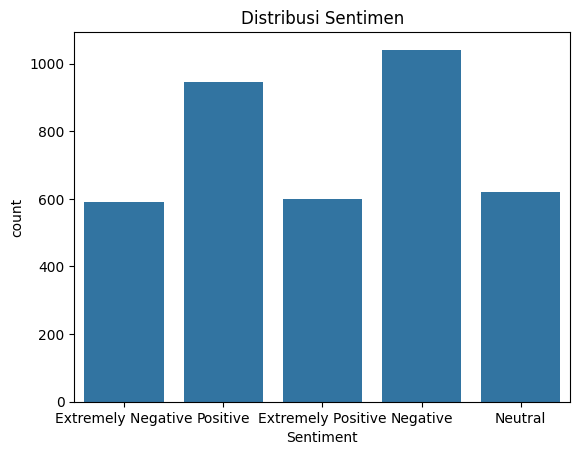

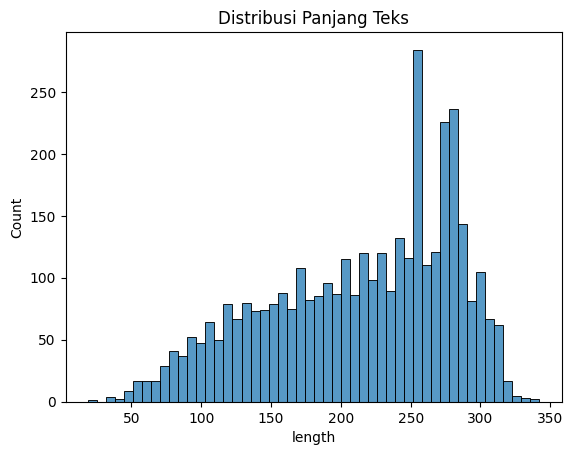

In [75]:
# Info dataset
df.info()
df.describe()

# Missing value
print(df.isnull().sum())

# Distribusi sentimen
sns.countplot(x='Sentiment', data=df)
plt.title('Distribusi Sentimen')
plt.show()

# Panjang teks
df['length'] = df['OriginalTweet'].astype(str).apply(len)

sns.histplot(df['length'], bins=50)
plt.title('Distribusi Panjang Teks')
plt.show()

**Data Cleaning**

**Note:** Berdasarkan informasi sebelumnya, karena kolom Location memiliki banyak missing value, dibandingkan menghilangkan baris kosong yang akan mempengaruhi OriginalTweet, maka kolom Location akan dihapus karena tidak digunakan

In [76]:
df = df.drop(columns=['Location'])
df.head()

,UserName,ScreenName,TweetAt,OriginalTweet,Sentiment,length
0,1,44953,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative,228
1,2,44954,02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive,193
2,3,44955,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive,73
3,4,44956,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative,318
4,5,44957,03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral,252


In [77]:
# Distribusi Sentimen
def map_sentiment(label):
    if label in ['Extremely Negative', 'Negative']:
        return 'Negative'
    elif label in ['Extremely Positive', 'Positive']:
        return 'Positive'
    else:
        return 'Neutral'

df['Sentiment'] = df['Sentiment'].apply(map_sentiment)
df.head()

,UserName,ScreenName,TweetAt,OriginalTweet,Sentiment,length
0,1,44953,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Negative,228
1,2,44954,02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive,193
2,3,44955,02-03-2020,Find out how you can protect yourself and love...,Positive,73
3,4,44956,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative,318
4,5,44957,03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral,252


**Agregasi Tweet per Tanggal**

In [78]:
# ubah ke datetime
df['TweetAt'] = pd.to_datetime(df['TweetAt'], format='%d-%m-%Y')

# ambil tanggal saja (tanpa jam)
df['Date'] = df['TweetAt'].dt.date

# hitung jumlah tweet per tanggal
tweets_per_day = df['Date'].value_counts().sort_index().reset_index()
tweets_per_day.columns = ['Date', 'Counts']
df.head()

,UserName,ScreenName,TweetAt,OriginalTweet,Sentiment,length,Date
0,1,44953,2020-03-02,TRENDING: New Yorkers encounter empty supermar...,Negative,228,2020-03-02
1,2,44954,2020-03-02,When I couldn't find hand sanitizer at Fred Me...,Positive,193,2020-03-02
2,3,44955,2020-03-02,Find out how you can protect yourself and love...,Positive,73,2020-03-02
3,4,44956,2020-03-02,#Panic buying hits #NewYork City as anxious sh...,Negative,318,2020-03-02
4,5,44957,2020-03-03,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral,252,2020-03-03


**Text Cleaning**

In [79]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

df['clean_text'] = df['OriginalTweet'].apply(clean_text)

In [80]:
df[['OriginalTweet', 'clean_text']].head()

,OriginalTweet,clean_text
0,TRENDING: New Yorkers encounter empty supermar...,trending new yorkers encounter empty supermark...
1,When I couldn't find hand sanitizer at Fred Me...,when i couldnt find hand sanitizer at fred mey...
2,Find out how you can protect yourself and love...,find out how you can protect yourself and love...
3,#Panic buying hits #NewYork City as anxious sh...,buying hits city as anxious shoppers stock up...
4,#toiletpaper #dunnypaper #coronavirus #coronav...,one week everyone buying baby milk powder the ...


**Stopword**

In [81]:
custom_stopwords = {
    'amp','rt','https','t','co','u','im','us',
    'covid','covid19','coronavirus','coronaviru',
    'will','now','one','still','get','going',
    'people','time','day','today','even'
}

stop_words = set(ENGLISH_STOP_WORDS).union(custom_stopwords)

# apply
df['clean_text'] = df['OriginalTweet'].apply(clean_text)

# cek hasil
df[['OriginalTweet', 'clean_text']].head()

,OriginalTweet,clean_text
0,TRENDING: New Yorkers encounter empty supermar...,trending new yorkers encounter supermarket she...
1,When I couldn't find hand sanitizer at Fred Me...,hand sanitizer fred meyer turned pack purellch...
2,Find out how you can protect yourself and love...,protect loved ones
3,#Panic buying hits #NewYork City as anxious sh...,buying hits city anxious shoppers stock foodam...
4,#toiletpaper #dunnypaper #coronavirus #coronav...,week buying baby milk powder buying toilet paper


**Tokenization**

In [82]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

In [83]:
df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,trending new yorkers encounter supermarket she...,"[trending, new, yorkers, encounter, supermarke..."
1,hand sanitizer fred meyer turned pack purellch...,"[hand, sanitizer, fred, meyer, turned, pack, p..."
2,protect loved ones,"[protect, loved, ones]"
3,buying hits city anxious shoppers stock foodam...,"[buying, hits, city, anxious, shoppers, stock,..."
4,week buying baby milk powder buying toilet paper,"[week, buying, baby, milk, powder, buying, toi..."


# **Exploratory Data Analysis (EDA)**

**Visualisasi Tweet per Tanggal**

/tmp/ipykernel_8443/1175915796.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


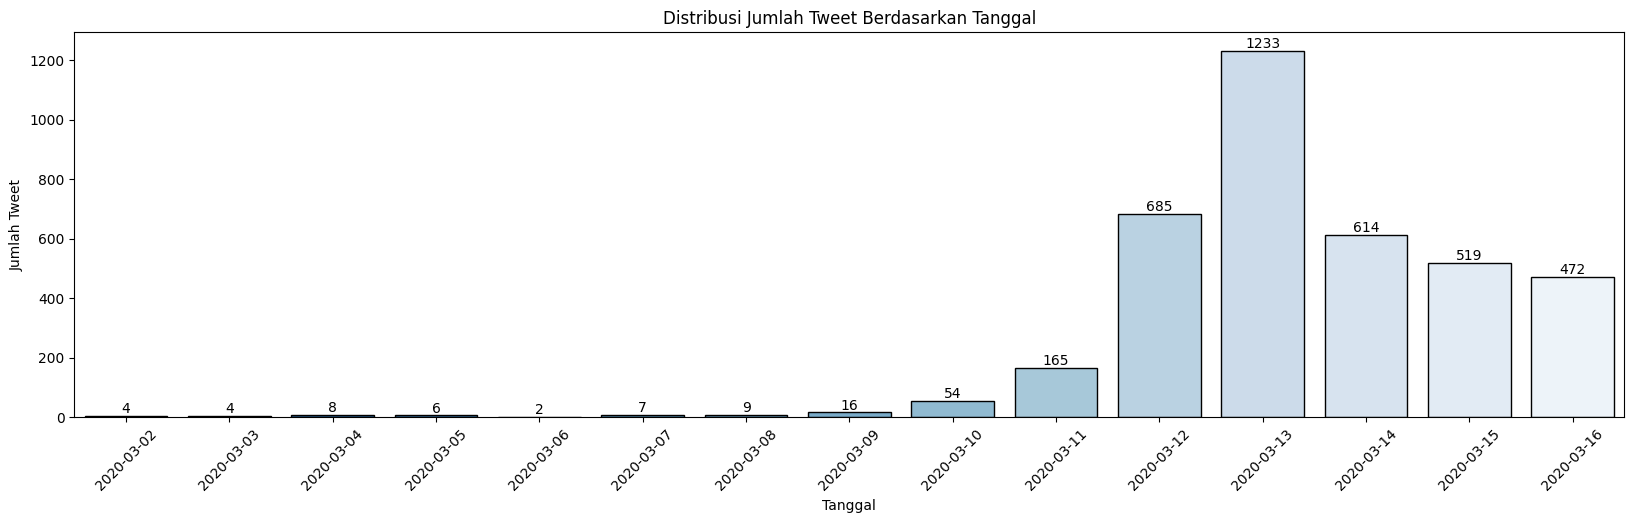

In [84]:
plt.figure(figsize=(20, 5))

ax = sns.barplot(
    x='Date',
    y='Counts',
    data=tweets_per_day,
    edgecolor='black',
    palette='Blues_r'
)

plt.title('Distribusi Jumlah Tweet Berdasarkan Tanggal')
plt.xticks(rotation=45)
plt.ylabel('Jumlah Tweet')
plt.xlabel('Tanggal')

# tampilkan label angka
for container in ax.containers:
    ax.bar_label(container)

plt.show()

**Distribusi Sentimen**

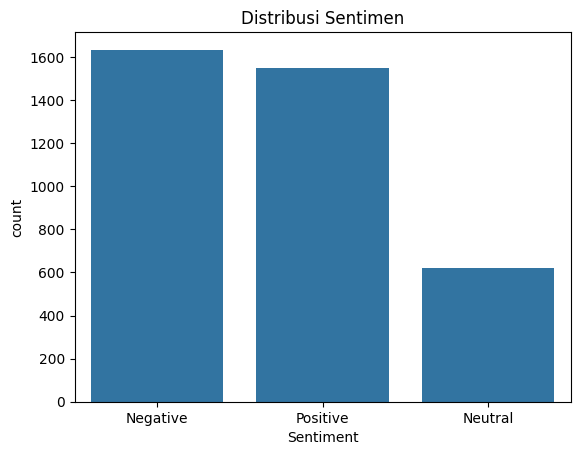

In [85]:
# Distribusi sentimen (setelah preprocessing)
sns.countplot(x='Sentiment', data=df)
plt.title('Distribusi Sentimen')
plt.show()

**Distribusi Presentase**

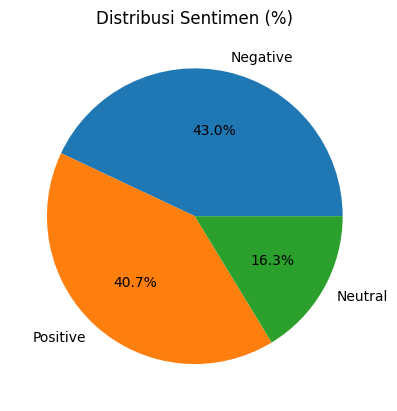

In [86]:
df['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribusi Sentimen (%)')
plt.ylabel('')
plt.show()

**Panjang Teks**

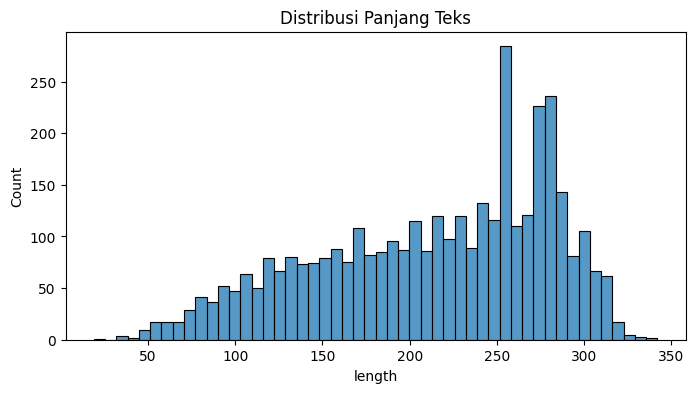

In [87]:
df['length'] = df['OriginalTweet'].astype(str).apply(len)

plt.figure(figsize=(8,4))
sns.histplot(df['length'], bins=50)
plt.title('Distribusi Panjang Teks')
plt.show()

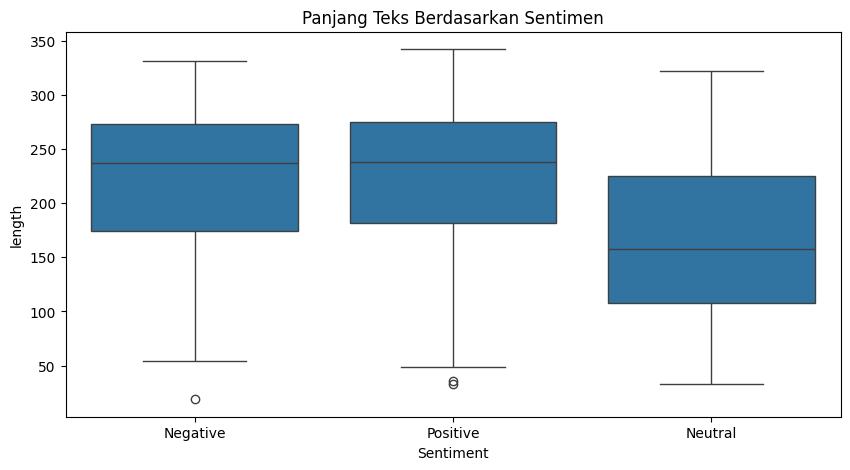

In [88]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Sentiment', y='length', data=df)
plt.title('Panjang Teks Berdasarkan Sentimen')
plt.show()

**Wordcloud**

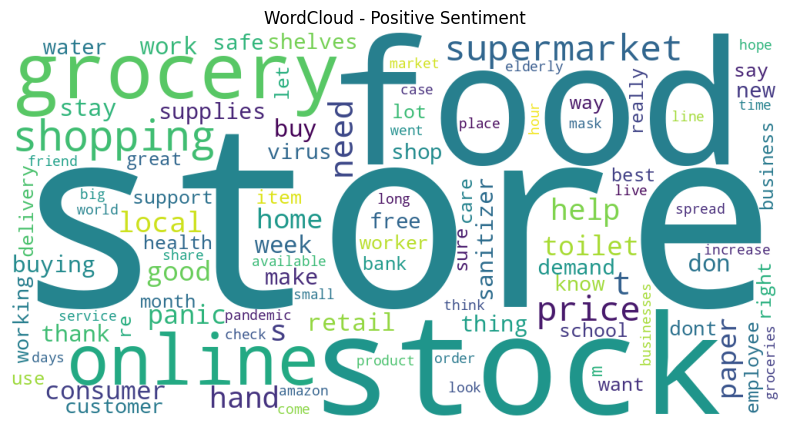

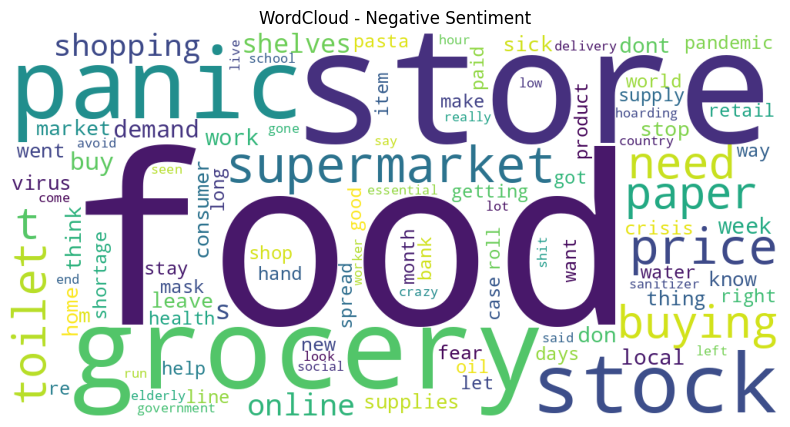

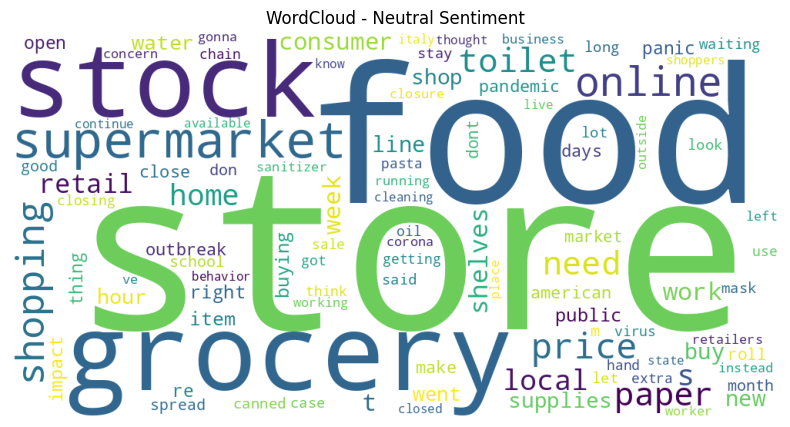

In [89]:
# fungsi buat bikin wordcloud
def plot_wordcloud(text, title):
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        colormap='viridis',
        max_words=100,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.title(title)
    plt.show()

# gabung text per sentimen
positive_text = " ".join(df[df['Sentiment'] == 'Positive']['clean_text'])
negative_text = " ".join(df[df['Sentiment'] == 'Negative']['clean_text'])
neutral_text  = " ".join(df[df['Sentiment'] == 'Neutral']['clean_text'])

# plot
plot_wordcloud(positive_text, "WordCloud - Positive Sentiment")
plot_wordcloud(negative_text, "WordCloud - Negative Sentiment")
plot_wordcloud(neutral_text, "WordCloud - Neutral Sentiment")

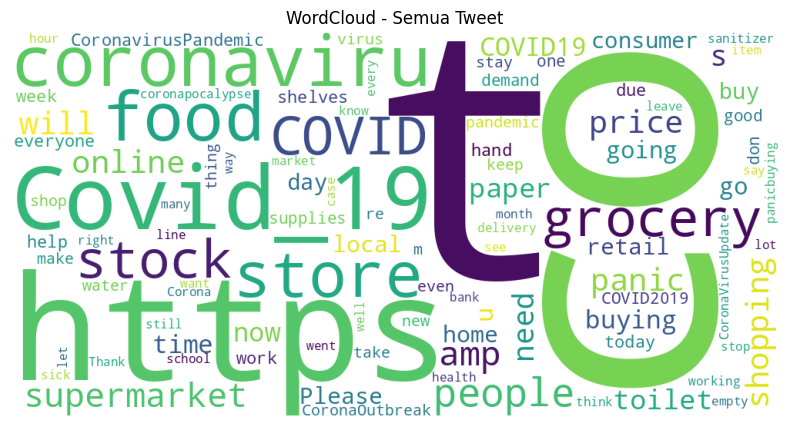

In [90]:
# gabung semua tweet
all_text = " ".join(df['OriginalTweet'].astype(str))

# plot
plot_wordcloud(all_text, "WordCloud - Semua Tweet")

**Bigram**

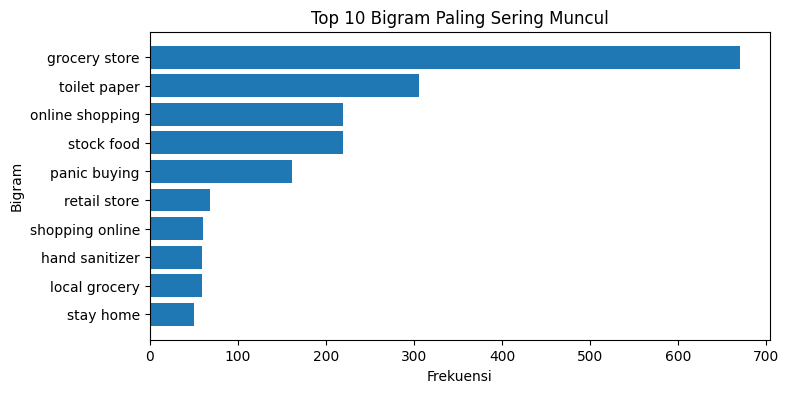

In [91]:
# buat bigram
bigram = CountVectorizer(ngram_range=(2,2), max_features=10)
X_bigram = bigram.fit_transform(df['clean_text'])

# hitung frekuensi
counts = np.sum(X_bigram.toarray(), axis=0)

# ambil nama bigram
features = bigram.get_feature_names_out()

# bikin dataframe biar rapi
import pandas as pd
bigram_df = pd.DataFrame({
    'bigram': features,
    'count': counts
}).sort_values(by='count', ascending=False)

# plot
plt.figure(figsize=(8,4))
plt.barh(bigram_df['bigram'], bigram_df['count'])
plt.gca().invert_yaxis()

plt.title('Top 10 Bigram Paling Sering Muncul')
plt.xlabel('Frekuensi')
plt.ylabel('Bigram')

plt.show()

# **Feature Extraction**

**TF-IDF**

In [92]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['Sentiment']

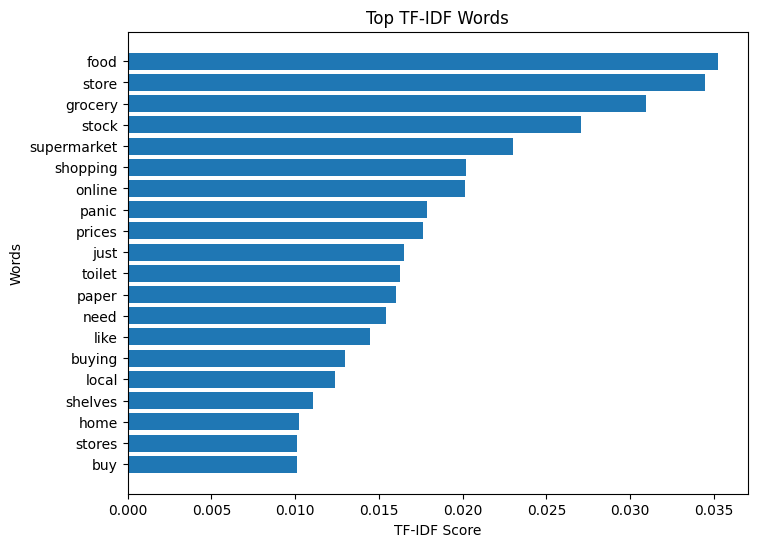

In [93]:
feature_names = tfidf.get_feature_names_out()
tfidf_mean = np.mean(X.toarray(), axis=0)
top_idx = np.argsort(tfidf_mean)[-20:]
top_words = [feature_names[i] for i in top_idx]

top_df = pd.DataFrame({
    'word': top_words,
    'score': tfidf_mean[top_idx]
})

top_df = top_df.sort_values(by='score', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(top_df['word'], top_df['score'])
plt.title('Top TF-IDF Words')
plt.xlabel('TF-IDF Score')
plt.ylabel('Words')
plt.show()

# **Train-Test Split**

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [95]:
print("Before split:")
print(y.value_counts(normalize=True))

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Before split:
Sentiment
Negative    0.429963
Positive    0.407056
Neutral     0.162981
Name: proportion, dtype: float64

Train:
Sentiment
Negative    0.429888
Positive    0.407176
Neutral     0.162936
Name: proportion, dtype: float64

Test:
Sentiment
Negative    0.430263
Positive    0.406579
Neutral     0.163158
Name: proportion, dtype: float64


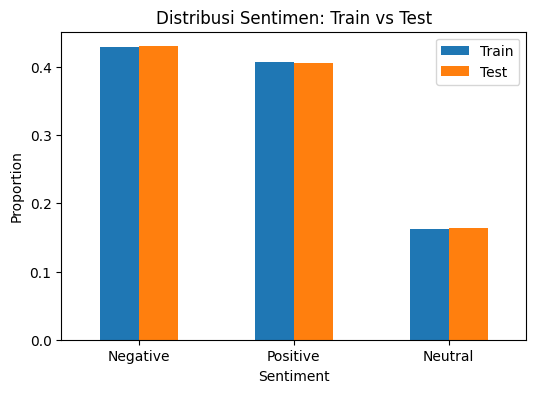

In [96]:
train_dist = y_train.value_counts(normalize=True)
test_dist = y_test.value_counts(normalize=True)

df_dist = pd.DataFrame({
    'Train': train_dist,
    'Test': test_dist
})

df_dist.plot(kind='bar', figsize=(6,4))
plt.title('Distribusi Sentimen: Train vs Test')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

# **Modelling**

## **Machine Learning**

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [98]:
model_lr = LogisticRegression(max_iter=1000)
model_nb = MultinomialNB()
model_svm = LinearSVC()

In [99]:
model_lr.fit(X_train, y_train)
model_nb.fit(X_train, y_train)
model_svm.fit(X_train, y_train)

LinearSVC()

In [100]:
y_pred_lr = model_lr.predict(X_test)
y_pred_nb = model_nb.predict(X_test)
y_pred_svm = model_svm.predict(X_test)

In [101]:
print("\nLogistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\nNaive Bayes:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

print("\nSVM:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


Logistic Regression:
Accuracy: 0.6855263157894737
              precision    recall  f1-score   support

    Negative       0.67      0.82      0.73       327
     Neutral       0.90      0.23      0.36       124
    Positive       0.69      0.73      0.71       309

    accuracy                           0.69       760
   macro avg       0.75      0.59      0.60       760
weighted avg       0.71      0.69      0.66       760


Naive Bayes:
Accuracy: 0.6039473684210527
              precision    recall  f1-score   support

    Negative       0.60      0.81      0.69       327
     Neutral       0.00      0.00      0.00       124
    Positive       0.61      0.63      0.62       309

    accuracy                           0.60       760
   macro avg       0.40      0.48      0.44       760
weighted avg       0.51      0.60      0.55       760


SVM:
Accuracy: 0.6868421052631579
              precision    recall  f1-score   support

    Negative       0.71      0.76      0.74       327


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [102]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results_df

,Model,Accuracy
0,Logistic Regression,0.685526
1,Naive Bayes,0.603947
2,SVM,0.686842


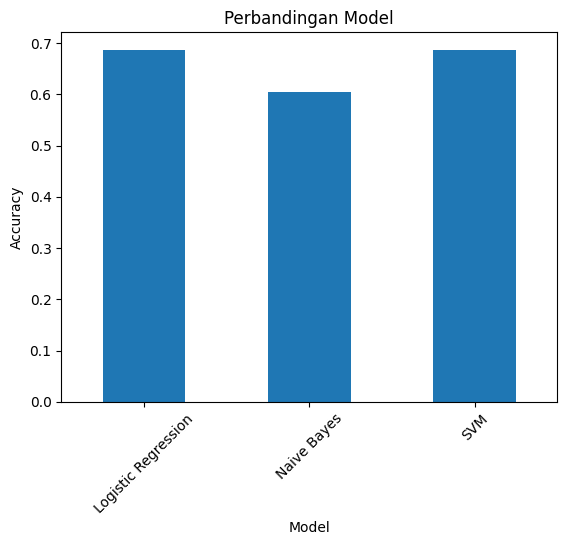

In [103]:
results_df.plot(x='Model', y='Accuracy', kind='bar', legend=False)
plt.title("Perbandingan Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

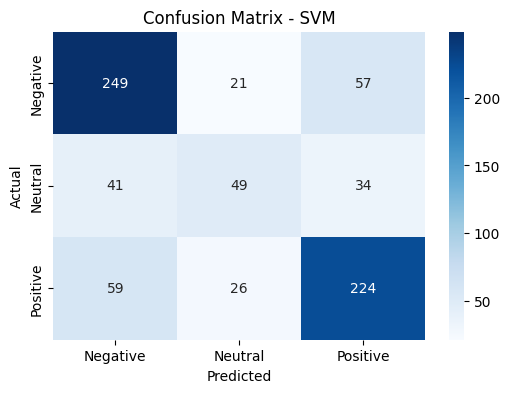

In [104]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

**Analisis Error**

In [105]:
results = pd.DataFrame({
    'text': df.loc[y_test.index, 'clean_text'],
    'actual': y_test,
    'predicted': y_pred_svm
})

errors = results[results['actual'] != results['predicted']]
errors.head()

,text,actual,predicted
1909,watch advantage like virus spread fast stock s...,Negative,Positive
3098,attn beer twitter twitterers beer stock beer b...,Positive,Neutral
1709,species fuckign stupid buy toilet paper highly...,Negative,Positive
1093,supermarket stockpile things like pasta rice c...,Positive,Negative
286,hard decide want hodl ccdcv token place declar...,Negative,Positive


## **BERT**

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['Sentiment'], test_size=0.2, random_state=42
)

In [107]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [108]:
def predict_sentiment(text):
    try:
        result = classifier(str(text)[:512])[0]
        return result['label']
    except:
        return 'LABEL_1'

In [109]:
label_map = {
    'LABEL_0': 'Negative',
    'LABEL_1': 'Neutral',
    'LABEL_2': 'Positive'
}

In [110]:
test_df = pd.DataFrame({
    'text': X_test,
    'actual': y_test
})

test_df['bert_pred'] = test_df['text'].apply(predict_sentiment)
test_df['bert_pred'] = test_df['bert_pred'].map(label_map)

In [111]:
print(classification_report(test_df['actual'], test_df['bert_pred']))

              precision    recall  f1-score   support

    Negative       0.70      0.51      0.59       327
     Neutral       0.23      0.87      0.37       118
    Positive       0.86      0.22      0.35       315

    accuracy                           0.45       760
   macro avg       0.60      0.54      0.44       760
weighted avg       0.69      0.45      0.46       760



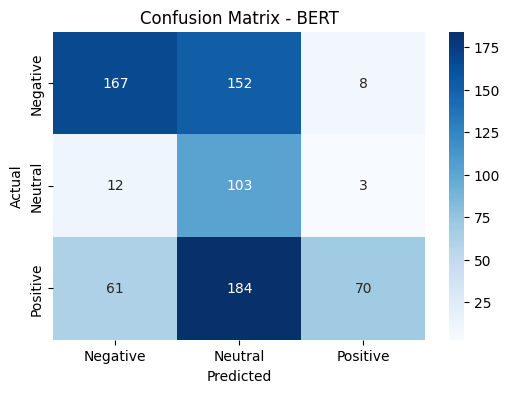

In [112]:
cm = confusion_matrix(test_df['actual'], test_df['bert_pred'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BERT")
plt.show()